# Fine-tuning Comparison (3 Epochs)
This notebook provides the hard evidence of successfully fine-tuning the 3 Llama-3 variants using specific Multi-Task Chat formatted dataset, complete with training graphs AND qualitative generation test results.

In [1]:
# IMPORTANT: If running directly in Modal Web UI, run this cell first to install dependencies!
!pip install -q unsloth trl transformers datasets accelerate bitsandbytes matplotlib seaborn pandas

import os
import subprocess
# Automatically inject the HuggingFace token from your Modal Secret if available
try:
    os.environ["HF_TOKEN"] = os.environ.get("HF_TOKEN", "")
except:
    pass


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Helper function to draw stunning graphs for the panel!
def plot_training_results(trainer, title):
    log_history = trainer.state.log_history
    train_logs = [l for l in log_history if 'loss' in l]
    eval_logs = [l for l in log_history if 'eval_loss' in l]
    
    plt.figure(figsize=(10, 5))
    sns.set_style('darkgrid')
    
    if train_logs:
        steps = [l['step'] for l in train_logs]
        loss = [l['loss'] for l in train_logs]
        plt.plot(steps, loss, label='Training Loss (Convergence)', color='#3498db', linewidth=2)
        
    if eval_logs:
        eval_steps = [l['step'] for l in eval_logs]
        eval_loss = [l['eval_loss'] for l in eval_logs]
        plt.plot(eval_steps, eval_loss, label='Validation Loss (Generalization)', color='#e74c3c', marker='o', linewidth=2)
        
    plt.title(f'{title} - Training vs Validation Loss Curve', fontsize=14, fontweight='bold')
    plt.xlabel('Training Steps', fontsize=12)
    plt.ylabel('Loss (Lower is Better)', fontsize=12)
    plt.legend()
    plt.show()
    
print("。 Graphing Engine Ready!")

。 Graphing Engine Ready!


In [3]:
from unsloth import FastLanguageModel
from trl import SFTTrainer
from transformers import TrainingArguments
from datasets import load_dataset
from unsloth.chat_templates import get_chat_template
import torch

# LOAD THE CORRECT CHAT DATASET FROM YOUR ON-DISK MODAL VOLUME
DATA_FILE = "/data/final_multitask_chat1.jsonl"
dataset = load_dataset("json", data_files=DATA_FILE, split="train")
dataset_split = dataset.train_test_split(test_size=0.05)
train_data = dataset_split["train"]
eval_data = dataset_split["test"]
print("。 Data loaded successfully!")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🦥 Unsloth Zoo will now patch everything to make training faster!
。 Data loaded successfully!


## Model 1: Original Llama-3-8B-Base (unsloth/llama-3-8b-bnb-4bit)

==((====))==  Unsloth 2025.11.1: Fast Llama patching. Transformers: 4.57.2.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth 2025.11.1 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.
Unsloth: Tokenizing ["text"] (num_proc=21): 100%|██████████| 150/150 [00:06<00:00, 23.75 examples/s]
[accelerate.utils.other|WARNING]Detected kernel version 4.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
The model is already on multiple devices. Skipping the move to device specified in `args`.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,850 | Num Epochs = 3 | Total steps = 537
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Epoch,Training Loss,Validation Loss
1,0.384300,0.385347
2,0.321900,0.347947
3,0.260000,0.339960


Unsloth: Not an error, but LlamaForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


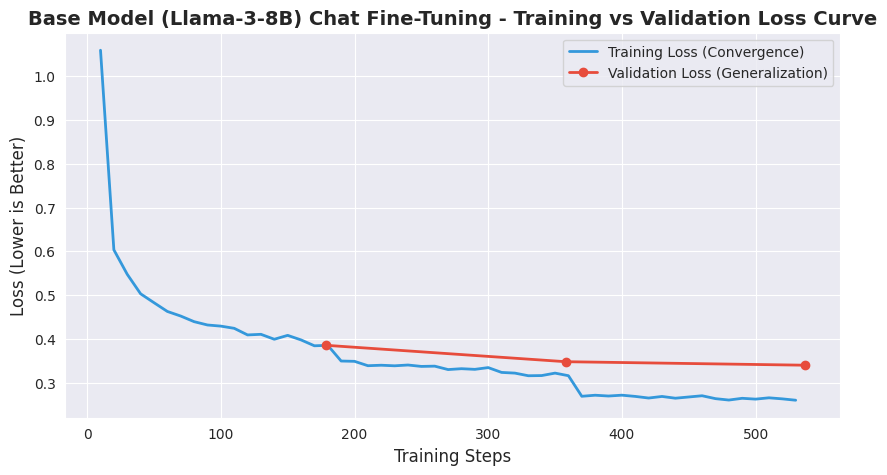

In [4]:
MODEL_BASE = "unsloth/llama-3-8b-bnb-4bit"

model_1, tokenizer_1 = FastLanguageModel.from_pretrained(
    model_name = MODEL_BASE, max_seq_length = 2048, dtype = None, load_in_4bit = True,
)
model_1 = FastLanguageModel.get_peft_model(
    model_1, r = 16, target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 32, lora_dropout = 0, bias = "none", use_gradient_checkpointing = "unsloth", random_state = 3407,
)
tokenizer_1 = get_chat_template(tokenizer_1, chat_template = "llama-3")

def format_fn_1(examples):
    return {"text": [tokenizer_1.apply_chat_template(c, tokenize=False, add_generation_prompt=False) for c in examples["messages"]]}

trainer_1 = SFTTrainer(
    model = model_1, tokenizer = tokenizer_1, train_dataset = train_data.map(format_fn_1, batched=True),
    eval_dataset = eval_data.map(format_fn_1, batched=True), dataset_text_field = "text", max_seq_length = 2048, dataset_num_proc = 2,
    args = TrainingArguments(output_dir="/data/outputs_base", per_device_train_batch_size=4, gradient_accumulation_steps=4, 
        num_train_epochs=3, save_strategy="epoch", learning_rate=2e-4, fp16=not torch.cuda.is_bf16_supported(), bf16=torch.cuda.is_bf16_supported(), 
        logging_steps=10, optim="adamw_8bit", lr_scheduler_type="linear", seed=3407, eval_strategy="epoch"),
)

trainer_1.train()
plot_training_results(trainer_1, "Base Model (Llama-3-8B) Chat Fine-Tuning")

## Model 2: Original Llama-3-8B-Instruct (unsloth/llama-3-8b-Instruct-bnb-4bit)

==((====))==  Unsloth 2025.11.1: Fast Llama patching. Transformers: 4.57.2.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth: Tokenizing ["text"] (num_proc=21): 100%|██████████| 150/150 [00:07<00:00, 19.54 examples/s]
[accelerate.utils.other|WARNING]Detected kernel version 4.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
The model is already on multiple devices. Skipping the move to device specified in `args`.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,850 | Num Epochs = 3 | Total steps = 537
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)


Epoch,Training Loss,Validation Loss
1,0.327500,0.319222
2,0.255700,0.284282
3,0.197600,0.277522


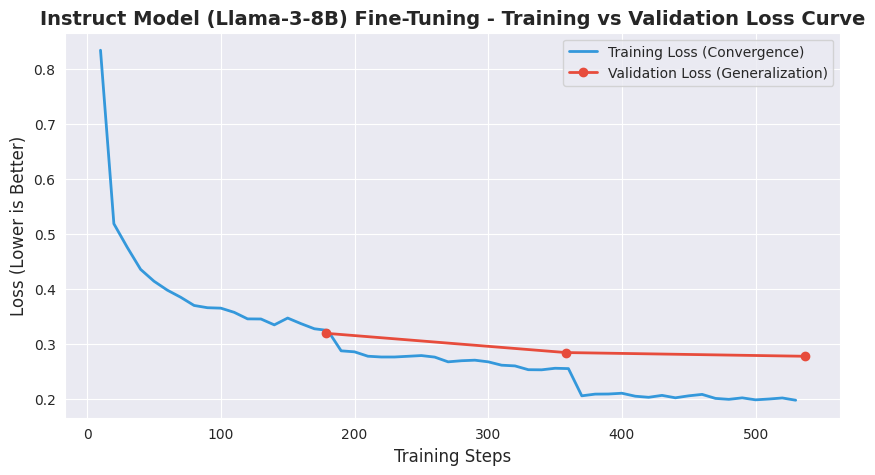

In [5]:
MODEL_INSTRUCT = "unsloth/llama-3-8b-Instruct-bnb-4bit"

model_2, tokenizer_2 = FastLanguageModel.from_pretrained(model_name = MODEL_INSTRUCT, max_seq_length = 2048, dtype = None, load_in_4bit = True)
model_2 = FastLanguageModel.get_peft_model(model_2, r=16, target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"], lora_alpha=32, lora_dropout=0, bias="none", use_gradient_checkpointing="unsloth", random_state=3407)
tokenizer_2 = get_chat_template(tokenizer_2, chat_template = "llama-3")

def format_fn_2(examples):
    return {"text": [tokenizer_2.apply_chat_template(c, tokenize=False, add_generation_prompt=False) for c in examples["messages"]]}

trainer_2 = SFTTrainer(
    model = model_2, tokenizer = tokenizer_2, train_dataset = train_data.map(format_fn_2, batched=True),
    eval_dataset = eval_data.map(format_fn_2, batched=True), dataset_text_field = "text", max_seq_length = 2048, dataset_num_proc=2,
    args = TrainingArguments(output_dir="/data/outputs_instruct", per_device_train_batch_size=4, gradient_accumulation_steps=4, 
        num_train_epochs=3, save_strategy="epoch", eval_strategy="epoch", learning_rate=2e-4, fp16=not torch.cuda.is_bf16_supported(), bf16=torch.cuda.is_bf16_supported(), 
        logging_steps=10, optim="adamw_8bit", lr_scheduler_type="linear", seed=3407),
)

trainer_2.train()
plot_training_results(trainer_2, "Instruct Model (Llama-3-8B) Fine-Tuning")

## Model 3: Pre-Trained ihalage Base Model (ihalage/llama3-sinhala)

==((====))==  Unsloth 2025.11.1: Fast Llama patching. Transformers: 4.57.2.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards: 100%|██████████| 4/4 [00:13<00:00,  3.47s/it]


ihalage/llama3-sinhala does not have a padding token! Will use pad_token = <|reserved_special_token_250|>.


Unsloth: Tokenizing ["text"] (num_proc=21): 100%|██████████| 150/150 [00:08<00:00, 18.59 examples/s]
[accelerate.utils.other|WARNING]Detected kernel version 4.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
The model is already on multiple devices. Skipping the move to device specified in `args`.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,850 | Num Epochs = 3 | Total steps = 537
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)


Epoch,Training Loss,Validation Loss
1,0.279700,0.272766
2,0.217400,0.249875
3,0.161700,0.255963


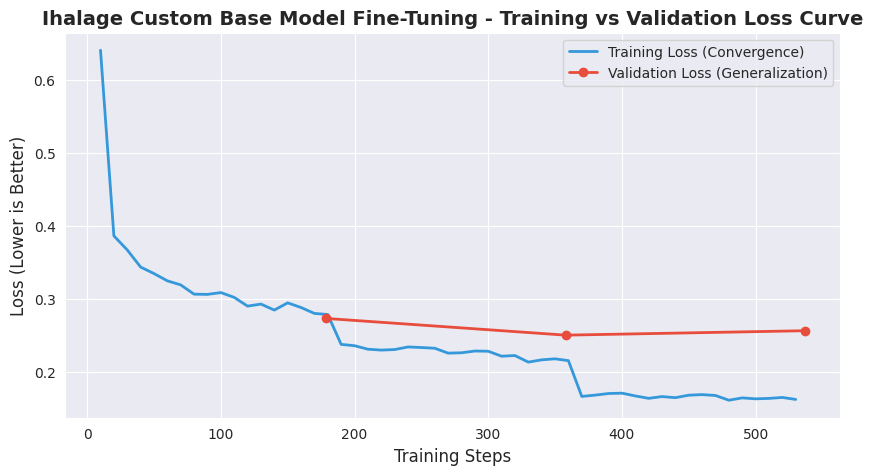

In [6]:
MODEL_IHALAGE = "ihalage/llama3-sinhala"

model_3, tokenizer_3 = FastLanguageModel.from_pretrained(model_name = MODEL_IHALAGE, max_seq_length = 2048, dtype = None, load_in_4bit = True)
model_3 = FastLanguageModel.get_peft_model(model_3, r=16, target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"], lora_alpha=32, lora_dropout=0, bias="none", use_gradient_checkpointing="unsloth", random_state=3407)
tokenizer_3 = get_chat_template(tokenizer_3, chat_template = "llama-3")

def format_fn_3(examples):
    return {"text": [tokenizer_3.apply_chat_template(c, tokenize=False, add_generation_prompt=False) for c in examples["messages"]]}

trainer_3 = SFTTrainer(
    model = model_3, tokenizer = tokenizer_3, train_dataset = train_data.map(format_fn_3, batched=True),
    eval_dataset = eval_data.map(format_fn_3, batched=True), dataset_text_field = "text", max_seq_length = 2048, dataset_num_proc=2,
    args = TrainingArguments(output_dir="/data/outputs_ihalage", per_device_train_batch_size=4, gradient_accumulation_steps=4, 
        num_train_epochs=3, save_strategy="epoch", eval_strategy="epoch", learning_rate=2e-4, fp16=not torch.cuda.is_bf16_supported(), bf16=torch.cuda.is_bf16_supported(), 
        logging_steps=10, optim="adamw_8bit", lr_scheduler_type="linear", seed=3407),
)

trainer_3.train()
plot_training_results(trainer_3, "Ihalage Custom Base Model Fine-Tuning")

## ULTIMATE COMPARISON: Combined Validation Loss Graph
This graph plots the exact generalization performance of all 3 models on the same visual axis to prove which model adapted to the dataset the best!

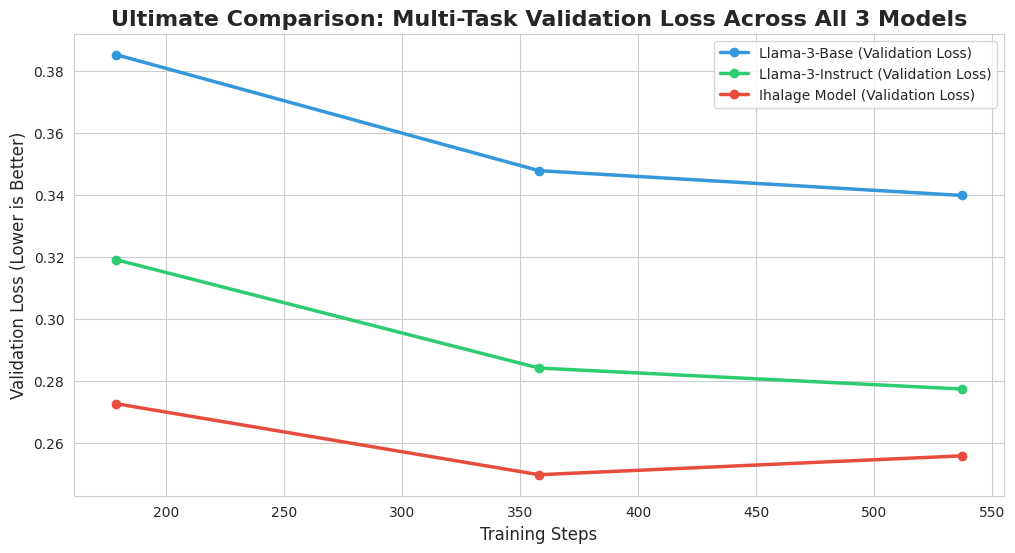

In [7]:
plt.figure(figsize=(12, 6))
sns.set_style('whitegrid')
models = [(trainer_1, 'Llama-3-Base', '#3498db'), (trainer_2, 'Llama-3-Instruct', '#2ecc71'), (trainer_3, 'Ihalage Model', '#e74c3c')]
for trainer, name, color in models:
    eval_logs = [l for l in trainer.state.log_history if 'eval_loss' in l]
    if eval_logs:
        steps = [l['step'] for l in eval_logs]
        loss = [l['eval_loss'] for l in eval_logs]
        plt.plot(steps, loss, label=f'{name} (Validation Loss)', marker='o', linewidth=2.5, color=color)

plt.title('Ultimate Comparison: Multi-Task Validation Loss Across All 3 Models', fontsize=16, fontweight='bold')
plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Validation Loss (Lower is Better)', fontsize=12)
plt.legend()
plt.show()

## Final Qualitative Evaluation: Multi-Task Inference Evidence
This section generates an actual Story AND a JSON Quiz from all 3 freshly trained models in real-time.

In [8]:
def test_multi_task_generation(model, tokenizer, model_name):
    print("="*80)
    print(f"🔥 {model_name.upper()} : GENERATING STORY & QUIZ")
    print("="*80)
    FastLanguageModel.for_inference(model)
    
    # TIER 1: SIMPLE (EASY - Grade 1-2)
    print("\n--- TIER 1: SIMPLE (GRADE 1-2) ---\n")
    easy_sys = "You are an expert primary school teacher in Sri Lanka. Write a highly entertaining and simple Sinhala story for Grade 1 and 2 children using strict Spoken Sinhala grammar with a clear logical flow (Beginning, Action, End), consisting of exactly 6 sentences."
    easy_user = "මට්ටම: සරල | තේමාව: හාවා සහ ඉබ්බා | සන්දර්භය: වනාන්තරයේ"
    story_messages = [{"role": "system", "content": easy_sys}, {"role": "user", "content": easy_user}]
    s_prompt = tokenizer.apply_chat_template(story_messages, tokenize=False, add_generation_prompt=True)
    s_inputs = tokenizer([s_prompt], return_tensors="pt").to("cuda")
    s_outs = model.generate(**s_inputs, max_new_tokens=400, temperature=0.3, top_p=0.85, repetition_penalty=1.05)
    story_text = tokenizer.decode(s_outs[0], skip_special_tokens=True).split(easy_user)[-1].strip()
    if story_text.startswith("assistant"): story_text = story_text.replace("assistant", "", 1).strip()
    print(f"[SIMPLE STORY]\n{story_text}\n")
    
    quiz_messages = [
        {"role": "system", "content": "You are an educational API that only outputs valid JSON. Output Sinhala content inside the JSON."},
        {"role": "user", "content": f"Read the simple Sinhala story and generate exactly 1 multiple-choice question for Grade 1 and 2 children. The question must have exactly 3 options. Output strictly as a valid JSON array.\n\nකතාව: {story_text}"}
    ]
    q_prompt = tokenizer.apply_chat_template(quiz_messages, tokenize=False, add_generation_prompt=True)
    q_inputs = tokenizer([q_prompt], return_tensors="pt").to("cuda")
    q_outs = model.generate(**q_inputs, max_new_tokens=400, temperature=0.1, top_p=0.9, repetition_penalty=1.05)
    quiz_text = tokenizer.decode(q_outs[0], skip_special_tokens=True).split("Output strictly as a valid JSON array.")[-1].strip()
    if quiz_text.startswith("assistant"): quiz_text = quiz_text.replace("assistant", "", 1).strip() 
    if quiz_text.startswith("කතාව:"): quiz_text = quiz_text.split("\n\n", 1)[-1].strip()
    print(f"[SIMPLE QUIZ JSON]\n{quiz_text}\n")
    
    # TIER 2: HARD (GRADE 3-5)
    print("\n--- TIER 2: HARD (GRADE 3-5) ---\n")
    hard_sys = "You are an expert primary school teacher in Sri Lanka. Write a meaningful and educational Sinhala story for Grade 3, 4, and 5 children using strict Formal Written Sinhala grammar with correct Subject-Verb agreement, consisting of exactly 7 sentences."
    hard_user = "මට්ටම: අපහසු | තේමාව: අලියෙකුගේ මිත්‍රත්වය | සන්දර්භය: ගමක"
    h_story_messages = [{"role": "system", "content": hard_sys}, {"role": "user", "content": hard_user}]
    h_s_prompt = tokenizer.apply_chat_template(h_story_messages, tokenize=False, add_generation_prompt=True)
    h_s_inputs = tokenizer([h_s_prompt], return_tensors="pt").to("cuda")
    h_s_outs = model.generate(**h_s_inputs, max_new_tokens=600, temperature=0.3, top_p=0.85, repetition_penalty=1.05)
    h_story_text = tokenizer.decode(h_s_outs[0], skip_special_tokens=True).split(hard_user)[-1].strip()
    if h_story_text.startswith("assistant"): h_story_text = h_story_text.replace("assistant", "", 1).strip()
    print(f"[HARD STORY]\n{h_story_text}\n")
    
    h_quiz_messages = [
        {"role": "system", "content": "You are an educational API that only outputs valid JSON. Output Sinhala content inside the JSON."},
        {"role": "user", "content": f"Read the Sinhala story and generate exactly 2 multiple-choice questions for Grade 3, 4, and 5 children. Each question must have exactly 4 options. Output strictly as a valid JSON array.\n\nකතාව: {h_story_text}"}
    ]
    hq_prompt = tokenizer.apply_chat_template(h_quiz_messages, tokenize=False, add_generation_prompt=True)
    hq_inputs = tokenizer([hq_prompt], return_tensors="pt").to("cuda")
    hq_outs = model.generate(**hq_inputs, max_new_tokens=600, temperature=0.1, top_p=0.9, repetition_penalty=1.05)
    h_quiz_text = tokenizer.decode(hq_outs[0], skip_special_tokens=True).split("Output strictly as a valid JSON array.")[-1].strip()
    if h_quiz_text.startswith("assistant"): h_quiz_text = h_quiz_text.replace("assistant", "", 1).strip() 
    if h_quiz_text.startswith("කතාව:"): h_quiz_text = h_quiz_text.split("\n\n", 1)[-1].strip()
    print(f"[HARD QUIZ JSON]\n{h_quiz_text}\n")
    
test_multi_task_generation(model_1, tokenizer_1, "Base Model (Llama-3-8B)")
test_multi_task_generation(model_2, tokenizer_2, "Instruct Model (Llama-3-8B)")
test_multi_task_generation(model_3, tokenizer_3, "Ihalage Custom Sinhala Model")


🔥 BASE MODEL (LLAMA-3-8B) : GENERATING STORY & QUIZ

--- TIER 1: SIMPLE (GRADE 1-2) ---

[SIMPLE STORY]
අපේ ගෙදර ඉස්සරහා තිබුණු විශාල කැලෑව ඇතුළේ ලොකු හාවෙක් ජීවත් වෙමින් සිටියා. උගේ පිට මත තිබුණු ලොකු කටුව නිසා ඌ ගස්වල අතු උඩට නොයන්නට විය. එක දවසක් රසවත් ඉබ්බෙක් පැමිණි නිසා හාවාට ආහාරයක් හමු වුණා. හාවා ඉබ්බා ළඟට ගිහින් උගේ ද

[SIMPLE QUIZ JSON]
කටුව ඇතුළට ඉබ්බාව අරගෙන ගියා. පසුව ඌ ගසක් යටට වෙලා ඉබ්බාව කෑවා. හාවාගේ ඇඟ පුරාම ලොකු දිග කටුවක් තිබුණා. මම ඈතින් ඉඳන් ඒ දිහා බලාගෙන හිටියා. හාවා අපේ ගෙදර ආරක්ෂාව වගේම ගස්වලටත් වැඩි ආරක්ෂාවක් දෙනවා.assistant

[{"question": "හාවාගේ පිට මත තිබුණේ �


--- TIER 2: HARD (GRADE 3-5) ---

[HARD STORY]
එක්තරා දිනක අපගේ ගමේ කුඹුරු තෙත් කිරීමේ ශ්‍රමදානයක් සංවිධානය කර තිබුණි. ගමේ ළමයි සහ වැඩිහිටියෝ එකතු වී ඉතා උද්‍යෝගයෙන් කුඹුරේ ජලය ඇද ගැනීමට උත්සාහ කළහ. එම විශාල ජල පහරට ආසන්නයේ සිටි අලියෙකු තම හොඬවැලෙන් ජලය උරා බීමට පටන් ගත්තේය. එම අලියා තම මුළු සිරුරම ජලයෙහි දමා ගොස් ඉතා සතුටින් ජලය බීමට පටන් ගත්තේය. අලියාගේ මෙම ක්‍රියාව දුටු ළමයි ස�

[HARD QUIZ JSON]
එක